# EKF Validation for Pedestrian Tracking in BEV

이 노트북은 리팩토링된 2D Constant Velocity (CV) EKF 모델을 검증합니다.

## 목표
1. GT 궤적 데이터 로드 (BEV local [m] 좌표)
2. EKF 예측 결과 로드
3. GT vs EKF 비교 시각화
4. 오차 메트릭 계산 (Position Error, Velocity Error)
5. 시간에 따른 오차 변화 분석

## EKF 모델 스펙
- **State**: x = [X, Y, Vx, Vy]^T (BEV local [m], [m/s])
- **Motion Model**: Constant Velocity (CV)
- **Measurement**: z = [X, Y]^T (position only)
- **Process Noise**: White acceleration model (sigma_a)
- **Measurement Noise**: Isotropic (sigma_meas)

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import sys

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.trajectory.ekf_tracker_cv import EKFTrackerCV
from src.trajectory.ekf_manager import EKFManager
from src.core.config import load_yaml

print("✓ Libraries imported successfully")
print(f"Project root: {project_root}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
✓ Libraries imported successfully
Project root: /home/jba/Pedestrian-Tracking-for-Accident-Prevention
✓ Libraries imported successfully
Project root: /home/jba/Pedestrian-Tracking-for-Accident-Prevention


## 1. GT 궤적 데이터 로드

GT 궤적 JSON 파일에서 데이터를 읽어옵니다.
- 경로: `data/raw/{seq_id}/outputs/gt_trajectory_analysis/gt_trajectory_json/`
- 형식: 각 프레임마다 JSON 파일 (gt_traj_frame_XXXXXX.json)

In [2]:
def load_gt_trajectories(gt_json_dir):
    """
    Load GT trajectories from JSON files.
    
    Returns:
        dict: {track_id: [(frame_id, X, Y, Vx, Vy), ...]}
    """
    gt_json_dir = Path(gt_json_dir)
    
    # Dictionary to store trajectories per track_id
    # track_id -> list of (frame_id, X, Y, Vx, Vy)
    trajectories = {}
    
    json_files = sorted(gt_json_dir.glob("gt_traj_frame_*.json"))
    
    for json_file in json_files:
        with open(json_file, 'r') as f:
            data = json.load(f)
        
        frame_id = data['frame_id']
        
        for traj in data.get('trajectories', []):
            track_id = traj['track_id']
            
            if track_id not in trajectories:
                trajectories[track_id] = []
            
            # Get current position from trajectory_world
            traj_world = traj.get('trajectory_world', [])
            
            # Find the current frame (offset = 0)
            current_pos = None
            for pt in traj_world:
                if pt['frame_offset'] == 0:
                    current_pos = (pt['world_x'], pt['world_y'])
                    break
            
            if current_pos is None:
                continue
            
            # Estimate velocity from trajectory
            # Use offset -1 and +1 if available
            vx, vy = 0.0, 0.0
            prev_pt = None
            next_pt = None
            
            for pt in traj_world:
                if pt['frame_offset'] == -1:
                    prev_pt = pt
                elif pt['frame_offset'] == 1:
                    next_pt = pt
            
            # Central difference if both available
            if prev_pt and next_pt:
                dt_total = 0.2  # 2 frames * 0.1s
                vx = (next_pt['world_x'] - prev_pt['world_x']) / dt_total
                vy = (next_pt['world_y'] - prev_pt['world_y']) / dt_total
            elif next_pt:
                # Forward difference
                dt = 0.1
                vx = (next_pt['world_x'] - current_pos[0]) / dt
                vy = (next_pt['world_y'] - current_pos[1]) / dt
            elif prev_pt:
                # Backward difference
                dt = 0.1
                vx = (current_pos[0] - prev_pt['world_x']) / dt
                vy = (current_pos[1] - prev_pt['world_y']) / dt
            
            trajectories[track_id].append({
                'frame_id': frame_id,
                'X': current_pos[0],
                'Y': current_pos[1],
                'Vx': vx,
                'Vy': vy
            })
    
    # Sort each trajectory by frame_id
    for track_id in trajectories:
        trajectories[track_id] = sorted(trajectories[track_id], key=lambda x: x['frame_id'])
    
    print(f"Loaded GT trajectories for {len(trajectories)} tracks")
    for track_id, traj in list(trajectories.items())[:5]:
        print(f"  Track {track_id}: {len(traj)} frames")
    
    return trajectories

# Example usage (update path as needed)
# gt_dir = project_root / "data/raw/053/outputs/gt_trajectory_analysis/gt_trajectory_json"
# gt_trajectories = load_gt_trajectories(gt_dir)

## 2. EKF 시뮬레이션

GT 데이터를 measurement로 사용하여 EKF를 실행하고 결과를 저장합니다.

In [3]:
def run_ekf_on_gt(gt_trajectories, config_path=None):
    """
    Run EKF on GT trajectories (using GT as measurements).
    
    Args:
        gt_trajectories: dict from load_gt_trajectories
        config_path: path to EKF config YAML
    
    Returns:
        dict: {track_id: [(frame_id, X_ekf, Y_ekf, Vx_ekf, Vy_ekf), ...]}
    """
    ekf_manager = EKFManager(config_path=config_path)
    ekf_results = {}
    
    # Process each track
    for track_id, gt_traj in gt_trajectories.items():
        ekf_results[track_id] = []
        
        for i, gt_point in enumerate(gt_traj):
            frame_id = gt_point['frame_id']
            timestamp = frame_id * 0.1  # Assume 0.1s per frame
            
            # Measurement: GT position
            measurement = np.array([gt_point['X'], gt_point['Y']])
            
            # Update EKF
            ekf_pos = ekf_manager.update(track_id, measurement, timestamp)
            
            # Get full state
            state = ekf_manager.get_state(track_id)
            if state is not None:
                ekf_results[track_id].append({
                    'frame_id': frame_id,
                    'X': state[0],
                    'Y': state[1],
                    'Vx': state[2],
                    'Vy': state[3]
                })
    
    print(f"EKF simulation completed for {len(ekf_results)} tracks")
    return ekf_results

# Example usage
# ekf_results = run_ekf_on_gt(gt_trajectories)

## 3. 시각화: GT vs EKF 궤적 비교

선택한 track의 GT와 EKF 예측 궤적을 BEV 좌표계에 플롯합니다.

In [4]:
def plot_trajectory_comparison(gt_traj, ekf_traj, track_id):
    """
    Plot GT vs EKF trajectory for a single track.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Extract data
    gt_X = [p['X'] for p in gt_traj]
    gt_Y = [p['Y'] for p in gt_traj]
    gt_Vx = [p['Vx'] for p in gt_traj]
    gt_Vy = [p['Vy'] for p in gt_traj]
    frames_gt = [p['frame_id'] for p in gt_traj]
    
    ekf_X = [p['X'] for p in ekf_traj]
    ekf_Y = [p['Y'] for p in ekf_traj]
    ekf_Vx = [p['Vx'] for p in ekf_traj]
    ekf_Vy = [p['Vy'] for p in ekf_traj]
    frames_ekf = [p['frame_id'] for p in ekf_traj]
    
    # 1. XY trajectory plot
    ax = axes[0, 0]
    ax.plot(gt_X, gt_Y, 'g-o', label='GT', markersize=4, linewidth=2)
    ax.plot(ekf_X, ekf_Y, 'b--s', label='EKF', markersize=3, linewidth=1.5, alpha=0.7)
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_title(f'Track {track_id}: Trajectory in BEV')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    
    # 2. X position over time
    ax = axes[0, 1]
    ax.plot(frames_gt, gt_X, 'g-o', label='GT X', markersize=4)
    ax.plot(frames_ekf, ekf_X, 'b--s', label='EKF X', markersize=3, alpha=0.7)
    ax.set_xlabel('Frame')
    ax.set_ylabel('X [m]')
    ax.set_title('X Position over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Y position over time
    ax = axes[1, 0]
    ax.plot(frames_gt, gt_Y, 'g-o', label='GT Y', markersize=4)
    ax.plot(frames_ekf, ekf_Y, 'b--s', label='EKF Y', markersize=3, alpha=0.7)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Y [m]')
    ax.set_title('Y Position over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Velocity magnitude over time
    ax = axes[1, 1]
    gt_speed = [np.sqrt(vx**2 + vy**2) for vx, vy in zip(gt_Vx, gt_Vy)]
    ekf_speed = [np.sqrt(vx**2 + vy**2) for vx, vy in zip(ekf_Vx, ekf_Vy)]
    ax.plot(frames_gt, gt_speed, 'g-o', label='GT Speed', markersize=4)
    ax.plot(frames_ekf, ekf_speed, 'b--s', label='EKF Speed', markersize=3, alpha=0.7)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Speed [m/s]')
    ax.set_title('Velocity Magnitude over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example usage
# track_id = list(gt_trajectories.keys())[0]
# plot_trajectory_comparison(gt_trajectories[track_id], ekf_results[track_id], track_id)

## 4. 오차 메트릭 계산

Position 및 Velocity 오차를 계산합니다:
- **Position Error**: RMSE, ADE (Average Displacement Error)
- **Velocity Error**: RMSE of velocity components

In [5]:
def compute_errors(gt_trajectories, ekf_results):
    """
    Compute error metrics between GT and EKF trajectories.
    
    Returns:
        dict: Error metrics per track and overall statistics
    """
    all_errors = []
    
    for track_id in gt_trajectories:
        if track_id not in ekf_results:
            continue
        
        gt_traj = gt_trajectories[track_id]
        ekf_traj = ekf_results[track_id]
        
        # Match frames
        gt_dict = {p['frame_id']: p for p in gt_traj}
        ekf_dict = {p['frame_id']: p for p in ekf_traj}
        
        common_frames = sorted(set(gt_dict.keys()) & set(ekf_dict.keys()))
        
        if len(common_frames) == 0:
            continue
        
        errors = {
            'track_id': track_id,
            'num_frames': len(common_frames),
            'pos_errors': [],
            'vel_errors': [],
            'pos_error_x': [],
            'pos_error_y': []
        }
        
        for frame_id in common_frames:
            gt_p = gt_dict[frame_id]
            ekf_p = ekf_dict[frame_id]
            
            # Position error
            dx = ekf_p['X'] - gt_p['X']
            dy = ekf_p['Y'] - gt_p['Y']
            pos_err = np.sqrt(dx**2 + dy**2)
            errors['pos_errors'].append(pos_err)
            errors['pos_error_x'].append(abs(dx))
            errors['pos_error_y'].append(abs(dy))
            
            # Velocity error
            dvx = ekf_p['Vx'] - gt_p['Vx']
            dvy = ekf_p['Vy'] - gt_p['Vy']
            vel_err = np.sqrt(dvx**2 + dvy**2)
            errors['vel_errors'].append(vel_err)
        
        # Compute statistics for this track
        errors['pos_rmse'] = np.sqrt(np.mean(np.array(errors['pos_errors'])**2))
        errors['pos_ade'] = np.mean(errors['pos_errors'])
        errors['vel_rmse'] = np.sqrt(np.mean(np.array(errors['vel_errors'])**2))
        
        all_errors.append(errors)
    
    # Overall statistics
    if all_errors:
        all_pos_rmse = [e['pos_rmse'] for e in all_errors]
        all_vel_rmse = [e['vel_rmse'] for e in all_errors]
        
        overall = {
            'num_tracks': len(all_errors),
            'pos_rmse_mean': np.mean(all_pos_rmse),
            'pos_rmse_std': np.std(all_pos_rmse),
            'vel_rmse_mean': np.mean(all_vel_rmse),
            'vel_rmse_std': np.std(all_vel_rmse)
        }
        
        print("="*60)
        print("Overall Error Statistics")
        print("="*60)
        print(f"Number of tracks: {overall['num_tracks']}")
        print(f"Position RMSE:    {overall['pos_rmse_mean']:.4f} ± {overall['pos_rmse_std']:.4f} m")
        print(f"Velocity RMSE:    {overall['vel_rmse_mean']:.4f} ± {overall['vel_rmse_std']:.4f} m/s")
        print("="*60)
    else:
        overall = {}
    
    return {'per_track': all_errors, 'overall': overall}

# Example usage
# error_metrics = compute_errors(gt_trajectories, ekf_results)

## 5. 오차 시각화

시간에 따른 오차 변화를 플롯하여 EKF 성능을 분석합니다.

In [6]:
def plot_error_analysis(error_metrics):
    """
    Plot error distribution and statistics.
    """
    per_track_errors = error_metrics['per_track']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Position RMSE distribution
    ax = axes[0, 0]
    pos_rmses = [e['pos_rmse'] for e in per_track_errors]
    ax.hist(pos_rmses, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(pos_rmses), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(pos_rmses):.3f} m')
    ax.set_xlabel('Position RMSE [m]')
    ax.set_ylabel('Number of Tracks')
    ax.set_title('Distribution of Position RMSE')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Velocity RMSE distribution
    ax = axes[0, 1]
    vel_rmses = [e['vel_rmse'] for e in per_track_errors]
    ax.hist(vel_rmses, bins=20, color='coral', edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(vel_rmses), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {np.mean(vel_rmses):.3f} m/s')
    ax.set_xlabel('Velocity RMSE [m/s]')
    ax.set_ylabel('Number of Tracks')
    ax.set_title('Distribution of Velocity RMSE')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Position error over time (all tracks combined)
    ax = axes[1, 0]
    for e in per_track_errors[:10]:  # Plot first 10 tracks for clarity
        frames = list(range(len(e['pos_errors'])))
        ax.plot(frames, e['pos_errors'], alpha=0.5, linewidth=1)
    ax.set_xlabel('Frame (relative to track start)')
    ax.set_ylabel('Position Error [m]')
    ax.set_title('Position Error over Time (first 10 tracks)')
    ax.grid(True, alpha=0.3)
    
    # 4. Error statistics box plot
    ax = axes[1, 1]
    all_pos_errors = []
    for e in per_track_errors:
        all_pos_errors.extend(e['pos_errors'])
    
    data_to_plot = [
        all_pos_errors,
        [e['pos_rmse'] for e in per_track_errors],
        [e['pos_ade'] for e in per_track_errors]
    ]
    ax.boxplot(data_to_plot, labels=['All Errors', 'RMSE', 'ADE'])
    ax.set_ylabel('Position Error [m]')
    ax.set_title('Position Error Statistics')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Example usage
# plot_error_analysis(error_metrics)

## 6. 전체 실행 예제

위의 함수들을 사용하여 전체 검증 파이프라인을 실행합니다.

## 6. 미래 위치 예측 평가

EKF를 사용하여 미래 궤적을 예측하고 GT와 비교합니다.
- **예측 시점**: 각 프레임에서 미래 T 스텝 예측
- **평가 메트릭**: ADE (Average Displacement Error), FDE (Final Displacement Error)
- **예측 범위**: 1초 (10 프레임), 2초 (20 프레임)

In [ ]:
def evaluate_future_prediction(gt_trajectories, config_path=None, prediction_horizons=[10, 20]):
    """
    Evaluate EKF future prediction performance.
    
    For each frame, predict future trajectory and compare with GT.
    
    Args:
        gt_trajectories: dict from load_gt_trajectories
        config_path: path to EKF config YAML
        prediction_horizons: list of prediction steps [10, 20] = [1s, 2s]
    
    Returns:
        dict: Prediction error metrics
    """
    ekf_manager = EKFManager(config_path=config_path)
    
    prediction_errors = {h: [] for h in prediction_horizons}
    
    # Process each track
    for track_id, gt_traj in gt_trajectories.items():
        if len(gt_traj) < max(prediction_horizons) + 5:
            continue  # Skip short trajectories
        
        # Feed EKF with observations up to each frame, then predict future
        for i in range(len(gt_traj)):
            frame_id = gt_traj[i]['frame_id']
            timestamp = frame_id * 0.1
            
            # Measurement at current frame
            measurement = np.array([gt_traj[i]['X'], gt_traj[i]['Y']])
            
            # Update EKF
            ekf_manager.update(track_id, measurement, timestamp)
            
            # For each prediction horizon
            for horizon in prediction_horizons:
                # Check if we have GT for future frames
                future_idx = i + horizon
                if future_idx >= len(gt_traj):
                    continue
                
                # Predict future trajectory
                future_predictions = ekf_manager.predict_future(
                    track_id, 
                    steps=horizon, 
                    dt=0.1
                )
                
                if future_predictions is None or len(future_predictions) < horizon:
                    continue
                
                # Get GT future positions
                gt_future = []
                for j in range(1, horizon + 1):
                    if i + j >= len(gt_traj):
                        break
                    gt_future.append([gt_traj[i + j]['X'], gt_traj[i + j]['Y']])
                
                if len(gt_future) != horizon:
                    continue
                
                # Compute prediction errors
                errors = []
                for pred_pos, gt_pos in zip(future_predictions, gt_future):
                    dx = pred_pos[0] - gt_pos[0]
                    dy = pred_pos[1] - gt_pos[1]
                    error = np.sqrt(dx**2 + dy**2)
                    errors.append(error)
                
                # ADE: Average over all predicted steps
                ade = np.mean(errors)
                
                # FDE: Error at final predicted step
                fde = errors[-1]
                
                prediction_errors[horizon].append({
                    'track_id': track_id,
                    'frame_id': frame_id,
                    'ade': ade,
                    'fde': fde,
                    'errors': errors
                })
    
    # Compute statistics for each horizon
    results = {}
    for horizon in prediction_horizons:
        if not prediction_errors[horizon]:
            results[horizon] = None
            continue
        
        all_ade = [e['ade'] for e in prediction_errors[horizon]]
        all_fde = [e['fde'] for e in prediction_errors[horizon]]
        
        results[horizon] = {
            'num_predictions': len(prediction_errors[horizon]),
            'ade_mean': np.mean(all_ade),
            'ade_std': np.std(all_ade),
            'ade_median': np.median(all_ade),
            'fde_mean': np.mean(all_fde),
            'fde_std': np.std(all_fde),
            'fde_median': np.median(all_fde),
            'detailed_errors': prediction_errors[horizon]
        }
        
        print(f"\n{'='*60}")
        print(f"Prediction Horizon: {horizon} steps ({horizon * 0.1:.1f}s)")
        print(f"{'='*60}")
        print(f"Number of predictions: {results[horizon]['num_predictions']}")
        print(f"ADE: {results[horizon]['ade_mean']:.4f} ± {results[horizon]['ade_std']:.4f} m")
        print(f"     (median: {results[horizon]['ade_median']:.4f} m)")
        print(f"FDE: {results[horizon]['fde_mean']:.4f} ± {results[horizon]['fde_std']:.4f} m")
        print(f"     (median: {results[horizon]['fde_median']:.4f} m)")
    
    return results

# Example usage
# prediction_results = evaluate_future_prediction(gt_trajectories, config_path=str(ekf_config_path))

In [ ]:
def plot_prediction_errors(prediction_results):
    """
    Visualize future prediction errors.
    """
    horizons = sorted([h for h in prediction_results.keys() if prediction_results[h] is not None])
    
    if not horizons:
        print("No prediction results to plot")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. ADE comparison across horizons
    ax = axes[0, 0]
    ade_means = [prediction_results[h]['ade_mean'] for h in horizons]
    ade_stds = [prediction_results[h]['ade_std'] for h in horizons]
    horizon_labels = [f"{h*0.1:.1f}s" for h in horizons]
    
    x_pos = np.arange(len(horizons))
    ax.bar(x_pos, ade_means, yerr=ade_stds, capsize=5, color='steelblue', alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(horizon_labels)
    ax.set_xlabel('Prediction Horizon')
    ax.set_ylabel('ADE [m]')
    ax.set_title('Average Displacement Error vs Prediction Horizon')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. FDE comparison across horizons
    ax = axes[0, 1]
    fde_means = [prediction_results[h]['fde_mean'] for h in horizons]
    fde_stds = [prediction_results[h]['fde_std'] for h in horizons]
    
    ax.bar(x_pos, fde_means, yerr=fde_stds, capsize=5, color='coral', alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(horizon_labels)
    ax.set_xlabel('Prediction Horizon')
    ax.set_ylabel('FDE [m]')
    ax.set_title('Final Displacement Error vs Prediction Horizon')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Error distribution (box plot)
    ax = axes[1, 0]
    ade_data = [
        [e['ade'] for e in prediction_results[h]['detailed_errors']]
        for h in horizons
    ]
    bp = ax.boxplot(ade_data, labels=horizon_labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax.set_xlabel('Prediction Horizon')
    ax.set_ylabel('ADE [m]')
    ax.set_title('ADE Distribution')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Error growth over prediction steps (for longest horizon)
    ax = axes[1, 1]
    longest_horizon = max(horizons)
    detailed_errors = prediction_results[longest_horizon]['detailed_errors']
    
    # Average error at each step
    num_steps = longest_horizon
    step_errors = [[] for _ in range(num_steps)]
    
    for pred_data in detailed_errors:
        for step, error in enumerate(pred_data['errors']):
            step_errors[step].append(error)
    
    mean_errors = [np.mean(errors) for errors in step_errors]
    std_errors = [np.std(errors) for errors in step_errors]
    steps = np.arange(1, num_steps + 1)
    time_steps = steps * 0.1  # Convert to seconds
    
    ax.plot(time_steps, mean_errors, 'b-o', linewidth=2, markersize=4, label='Mean Error')
    ax.fill_between(time_steps, 
                     np.array(mean_errors) - np.array(std_errors),
                     np.array(mean_errors) + np.array(std_errors),
                     alpha=0.3, color='blue', label='±1 STD')
    ax.set_xlabel('Prediction Time [s]')
    ax.set_ylabel('Position Error [m]')
    ax.set_title(f'Error Growth over Prediction Steps ({longest_horizon*0.1:.1f}s horizon)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example usage
# plot_prediction_errors(prediction_results)

Sequence ID: 053
GT JSON dir: /home/jba/Pedestrian-Tracking-for-Accident-Prevention/data/raw/053/outputs/gt_trajectory_analysis/gt_trajectory_json
GT dir exists: True
Loaded GT trajectories for 5 tracks
  Track 2: 96 frames
  Track 3: 89 frames
  Track 10: 38 frames
  Track 16: 22 frames
  Track 23: 58 frames
EKF simulation completed for 5 tracks
Overall Error Statistics
Number of tracks: 5
Position RMSE:    0.0777 ± 0.0541 m
Velocity RMSE:    1.0149 ± 0.6293 m/s

Track 2


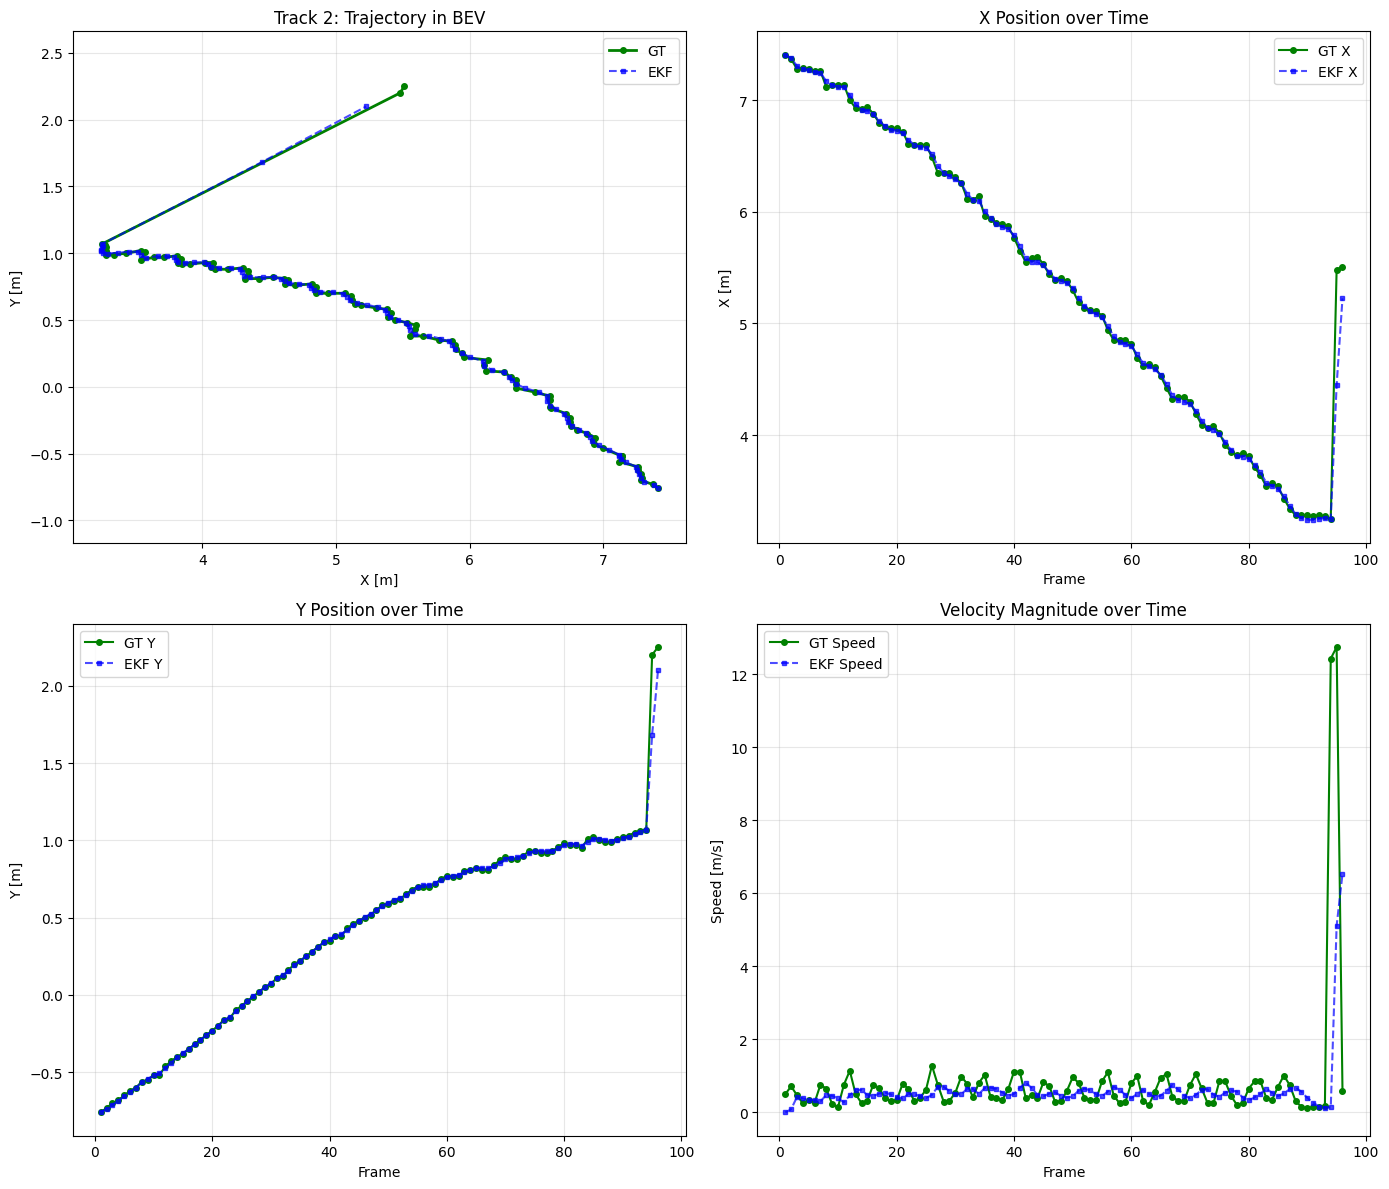


Track 3


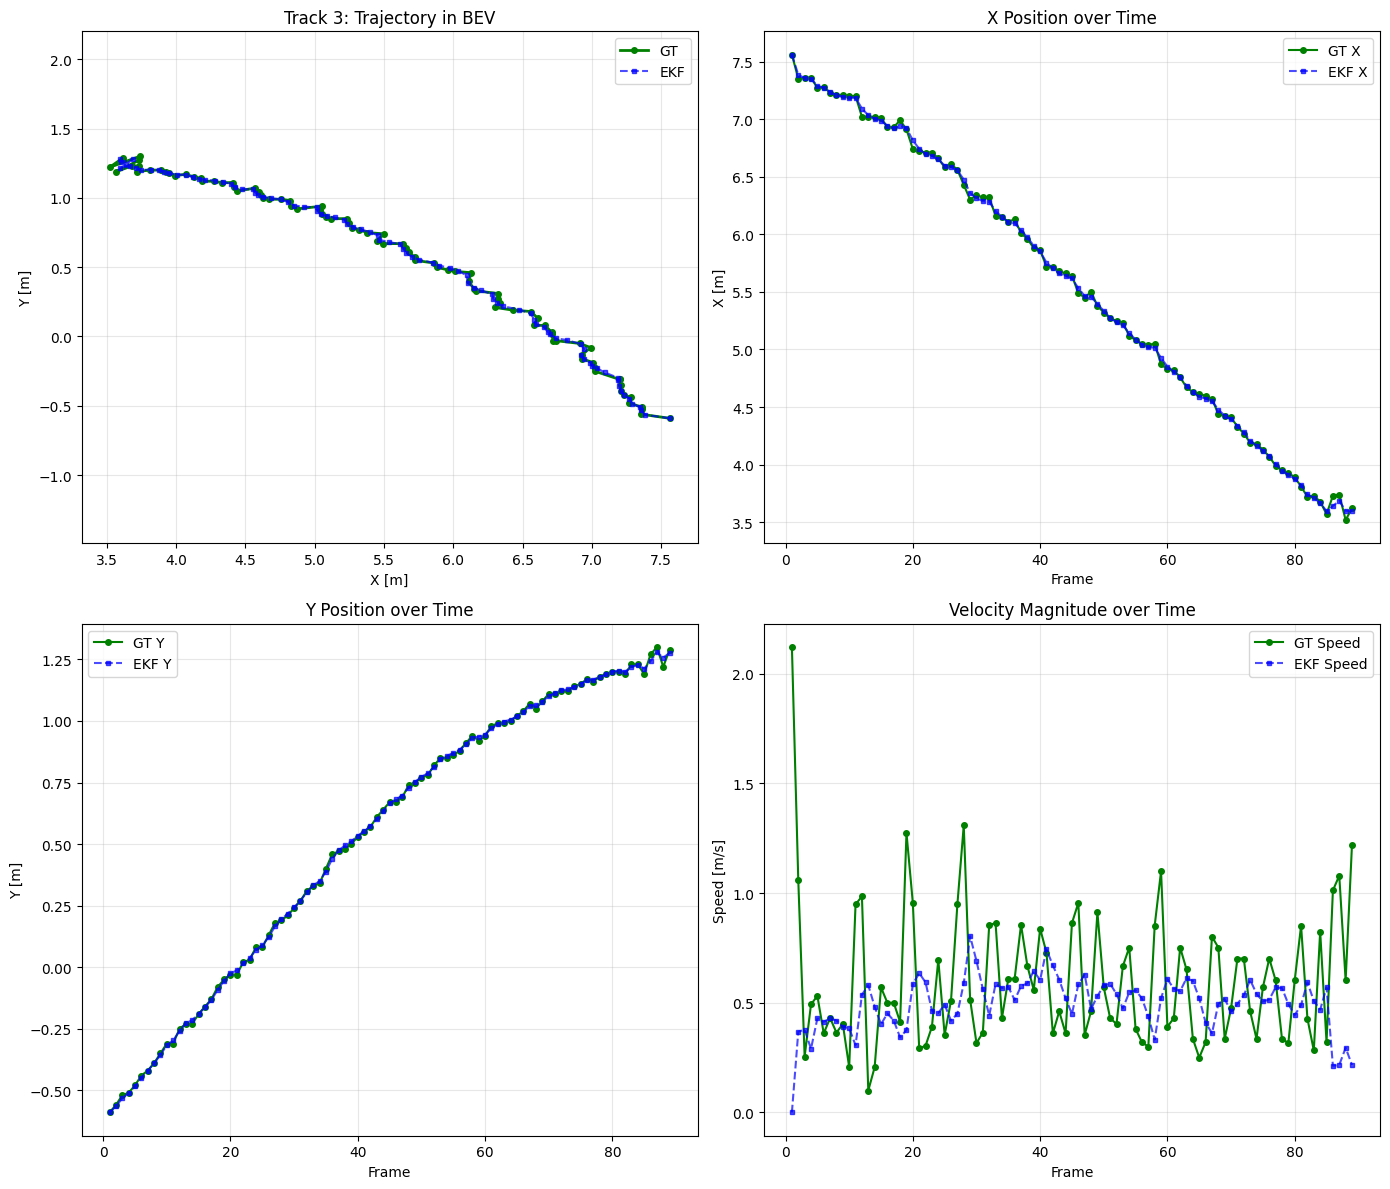


Track 10


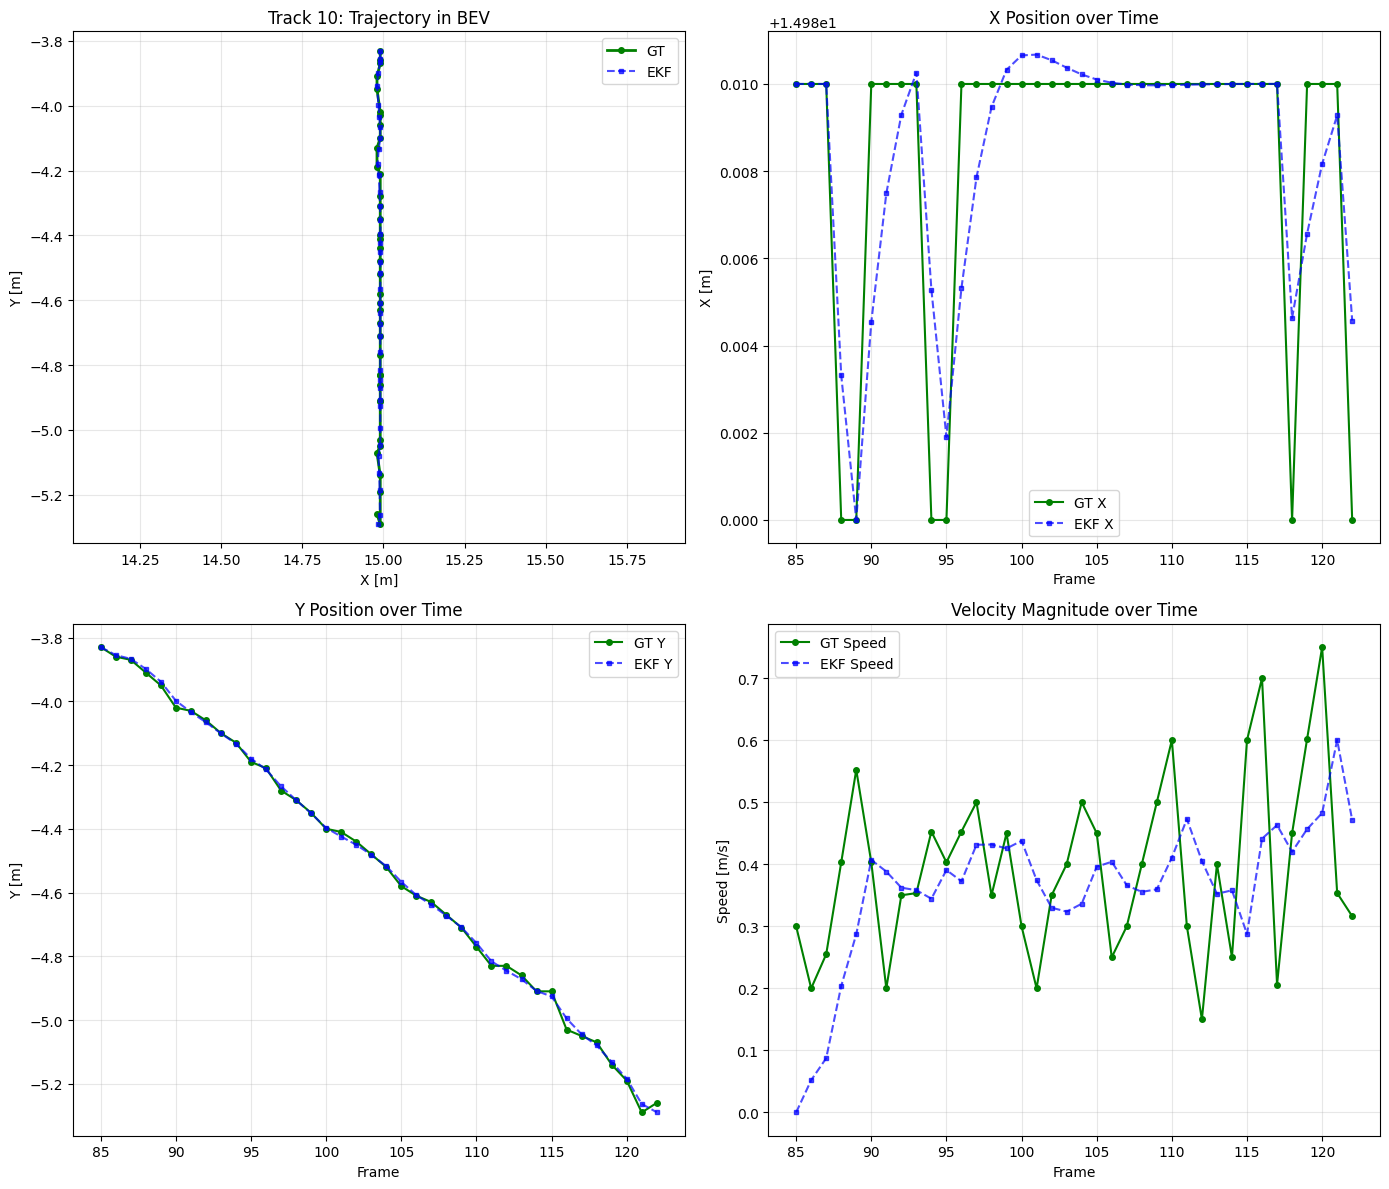

/tmp/ipykernel_29276/3501213994.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['All Errors', 'RMSE', 'ADE'])


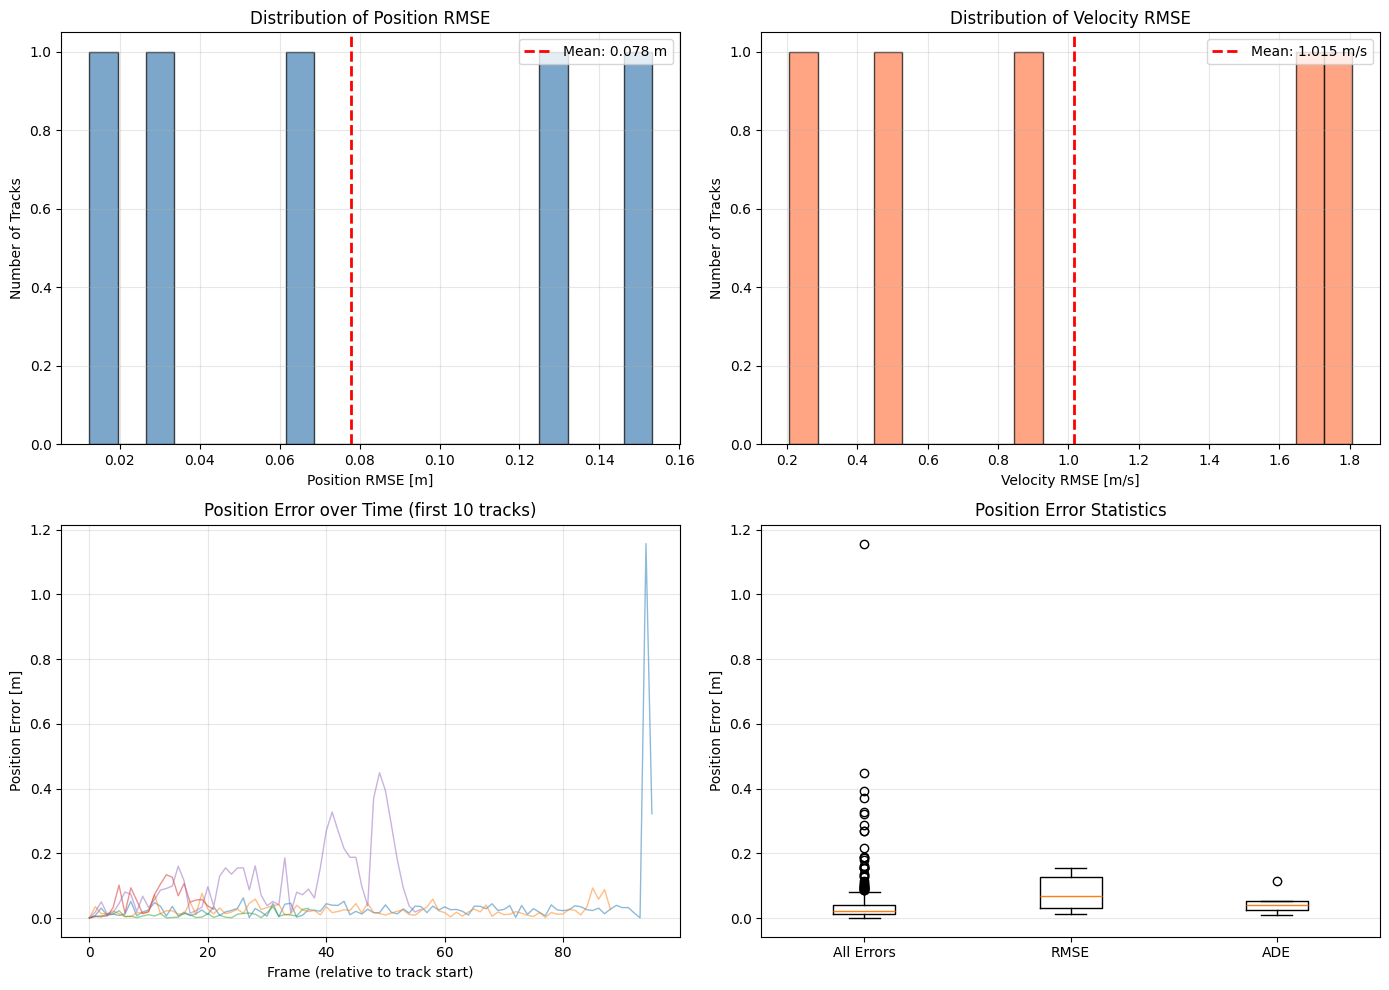

In [7]:
# Configuration
cfg = load_yaml("../configs/system.yaml")
seq_id = cfg["dataset_id"]

# Paths
gt_json_dir = project_root / f"data/raw/{seq_id}/outputs/gt_trajectory_analysis/gt_trajectory_json"
ekf_config_path = project_root / "configs/prediction/ekf.yaml"

print(f"Sequence ID: {seq_id}")
print(f"GT JSON dir: {gt_json_dir}")
print(f"GT dir exists: {gt_json_dir.exists()}")

# Step 1: Load GT trajectories
if gt_json_dir.exists():
    gt_trajectories = load_gt_trajectories(gt_json_dir)
    
    # Step 2: Run EKF on GT
    ekf_results = run_ekf_on_gt(gt_trajectories, config_path=str(ekf_config_path))
    
    # Step 3: Compute errors
    error_metrics = compute_errors(gt_trajectories, ekf_results)
    
    # Step 4: Plot comparison for a few tracks
    track_ids = list(gt_trajectories.keys())[:3]  # First 3 tracks
    for track_id in track_ids:
        if track_id in ekf_results:
            print(f"\n{'='*60}")
            print(f"Track {track_id}")
            print(f"{'='*60}")
            plot_trajectory_comparison(
                gt_trajectories[track_id], 
                ekf_results[track_id], 
                track_id
            )
    
    # Step 5: Plot error analysis
    plot_error_analysis(error_metrics)
    
else:
    print(f"ERROR: GT directory not found: {gt_json_dir}")
    print("Please run test_gt_trajectory_visualization.py first to generate GT trajectory JSONs.")

# Part 2: 20-Step Future Position Prediction (ADE/FDE Evaluation)

This section evaluates the EKF's ability to predict future positions using a **Constant Velocity (CV) model**.

## Objective
- Use GT trajectory as ideal measurements to perform EKF filtering
- At each time k, perform **20-step open-loop prediction** (H=20, ~2 seconds)
- Compute **ADE (Average Displacement Error)** and **FDE (Final Displacement Error)**
- Analyze prediction accuracy vs. prediction horizon

## Metrics
- **ADE**: Average position error over all future steps (1 to H)
- **FDE**: Position error at the final horizon step (H)
- **ADE(h)**: Average error at horizon h across all windows

## 1. Hyperparameter Configuration

In [7]:
# Prediction Configuration
dt_default = 0.1           # [s] Frame interval
H = 20                      # Prediction horizon (number of steps)
sigma_a = 3.0              # [m/s^2] Process noise - acceleration std
sigma_meas = 0.1           # [m] Measurement noise std
sigma_pos_init = 0.2       # [m] Initial position uncertainty
sigma_vel_init = 1.0       # [m/s] Initial velocity uncertainty

print("=== Prediction Configuration ===")
print(f"Time step (dt): {dt_default} s")
print(f"Prediction horizon (H): {H} steps = {H * dt_default} s")
print(f"Process noise (σ_a): {sigma_a} m/s²")
print(f"Measurement noise (σ_meas): {sigma_meas} m")

=== Prediction Configuration ===
Time step (dt): 0.1 s
Prediction horizon (H): 20 steps = 2.0 s
Process noise (σ_a): 3.0 m/s²
Measurement noise (σ_meas): 0.1 m


## 2. CV-EKF Class Definition

2D Constant Velocity Extended Kalman Filter implementation.

**State**: x = [X, Y, Vx, Vy]^T (BEV local [m], [m/s])

**Motion Model**: 
- F(dt) = [[1, 0, dt, 0], [0, 1, 0, dt], [0, 0, 1, 0], [0, 0, 0, 1]]
- Q(dt) = White acceleration model

**Measurement Model**:
- H = [[1, 0, 0, 0], [0, 1, 0, 0]] (position-only)
- R = diag([σ_meas², σ_meas²])

In [8]:
class CVEKF2D:
    """
    2D Constant Velocity Extended Kalman Filter
    
    State: x = [X, Y, Vx, Vy]^T
    - X, Y: Position in BEV local coordinates [m]
    - Vx, Vy: Velocity [m/s]
    
    Measurement: z = [X, Y]^T (position only)
    """
    
    def __init__(self, x0, P0, sigma_a, sigma_meas):
        """
        Initialize EKF
        
        Args:
            x0: Initial state [4,] (X, Y, Vx, Vy)
            P0: Initial covariance [4, 4]
            sigma_a: Process noise std (acceleration) [m/s^2]
            sigma_meas: Measurement noise std (position) [m]
        """
        self.x = x0.copy()
        self.P = P0.copy()
        self.sigma_a = sigma_a
        self.sigma_meas = sigma_meas
        
        # Measurement model (position only)
        self.H = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]], dtype=float)
        self.R = (sigma_meas ** 2) * np.eye(2)
    
    def F(self, dt):
        """State transition matrix for CV model"""
        return np.array([[1, 0, dt, 0 ],
                         [0, 1, 0 , dt],
                         [0, 0, 1 , 0 ],
                         [0, 0, 0 , 1 ]], dtype=float)
    
    def Q(self, dt):
        """
        Process noise covariance (white acceleration model)
        
        For 1D: Q_1d = σ_a² * [[dt⁴/4, dt³/2],
                                [dt³/2, dt²  ]]
        
        For 2D: Block diagonal with Q_x = Q_y = Q_1d
        """
        dt2 = dt * dt
        dt3 = dt2 * dt
        dt4 = dt2 * dt2
        sa2 = self.sigma_a ** 2
        
        # 1D block
        q11 = dt4 / 4.0 * sa2
        q12 = dt3 / 2.0 * sa2
        q22 = dt2 * sa2
        Qa = np.array([[q11, q12],
                       [q12, q22]], dtype=float)
        
        # 2D full matrix (block diagonal)
        Q = np.zeros((4, 4), dtype=float)
        Q[0:2, 0:2] = Qa  # X, Vx block
        Q[2:4, 2:4] = Qa  # Y, Vy block
        
        return Q
    
    def predict(self, dt):
        """
        Prediction step
        
        x = F @ x
        P = F @ P @ F^T + Q
        """
        F = self.F(dt)
        Q = self.Q(dt)
        
        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q
    
    def update(self, z):
        """
        Update step with measurement z = [X, Y]^T
        
        Innovation: y = z - H @ x
        Kalman gain: K = P @ H^T @ inv(S)
        State update: x = x + K @ y
        Covariance update: P = (I - K @ H) @ P
        """
        H = self.H
        R = self.R
        
        # Innovation
        y = z - H @ self.x
        
        # Innovation covariance
        S = H @ self.P @ H.T + R
        
        # Kalman gain
        K = self.P @ H.T @ np.linalg.inv(S)
        
        # State and covariance update
        I = np.eye(4)
        self.x = self.x + K @ y
        self.P = (I - K @ H) @ self.P

print("CVEKF2D class defined successfully")

CVEKF2D class defined successfully


## 3. Load GT Trajectory

Load ground truth trajectory data for a specific pedestrian track.

In [13]:
# Load GT trajectory (reuse function from Part 1)
sequence_id = "053"
track_id = 2  # Select a specific pedestrian track (track 2 has 97 points)

gt_traj_path = f"/home/jba/Pedestrian-Tracking-for-Accident-Prevention/data/raw/{sequence_id}/outputs/gt_trajectory_analysis/gt_trajectory_json"

# Find JSON files
gt_traj_files = sorted(Path(gt_traj_path).glob("*.json"))
print(f"Found {len(gt_traj_files)} GT trajectory files")

# Load from first file with trajectories (they contain full trajectories)
all_tracks = {}
for json_file in gt_traj_files:
    with open(json_file, 'r') as f:
        frame_data = json.load(f)
    
    if frame_data.get("trajectories"):
        for track in frame_data["trajectories"]:
            tid = track["track_id"]
            if tid not in all_tracks and "trajectory_world" in track:
                # Each track already has complete trajectory
                all_tracks[tid] = track["trajectory_world"]
        
        # Stop after finding trajectories (all files have same trajectory data)
        if all_tracks:
            break

# Extract specific track
if track_id not in all_tracks:
    print(f"Track {track_id} not found. Available tracks: {list(all_tracks.keys())}")
    if all_tracks:
        track_id = list(all_tracks.keys())[0]
        print(f"Using track {track_id} instead")
    else:
        raise ValueError("No tracks found in GT data")

track_points = sorted(all_tracks[track_id], key=lambda p: p["frame_id"])

# Convert to numpy arrays
X_gt = np.array([p["world_x"] for p in track_points], dtype=float)
Y_gt = np.array([p["world_y"] for p in track_points], dtype=float)
frame_ids = np.array([p["frame_id"] for p in track_points], dtype=int)

N = len(X_gt)
t = np.arange(N) * dt_default

print(f"\n=== GT Trajectory Loaded ===")
print(f"Track ID: {track_id}")
print(f"Number of frames: {N}")
print(f"Duration: {N * dt_default:.1f} s")
print(f"First point: ({X_gt[0]:.2f}, {Y_gt[0]:.2f}) m")
print(f"Last point: ({X_gt[-1]:.2f}, {Y_gt[-1]:.2f}) m")

Found 200 GT trajectory files

=== GT Trajectory Loaded ===
Track ID: 2
Number of frames: 97
Duration: 9.7 s
First point: (7.41, -0.76) m
Last point: (7.40, -0.78) m


## 4. EKF Filtering with GT as Measurements

Perform EKF filtering on the entire sequence using GT positions as ideal measurements.

In [14]:
# Initialize EKF
# Initial state from first two GT points
X0 = X_gt[0]
Y0 = Y_gt[0]

if N > 1:
    Vx0 = (X_gt[1] - X_gt[0]) / dt_default
    Vy0 = (Y_gt[1] - Y_gt[0]) / dt_default
else:
    Vx0 = 0.0
    Vy0 = 0.0

x0 = np.array([X0, Y0, Vx0, Vy0], dtype=float)

# Initial covariance
P0 = np.diag([sigma_pos_init**2, sigma_pos_init**2, 
              sigma_vel_init**2, sigma_vel_init**2])

# Create EKF instance
ekf = CVEKF2D(x0, P0, sigma_a, sigma_meas)

# Filtering loop
x_filt = np.zeros((N, 4))
x_filt[0] = x0

print("=== EKF Filtering ===")
print(f"Initial state: X={X0:.2f}, Y={Y0:.2f}, Vx={Vx0:.2f}, Vy={Vy0:.2f}")

for k in range(1, N):
    # Time step (fixed dt in this case)
    dt_k = t[k] - t[k-1]
    
    # Predict
    ekf.predict(dt_k)
    
    # Update with GT measurement
    z_k = np.array([X_gt[k], Y_gt[k]])
    ekf.update(z_k)
    
    # Store filtered state
    x_filt[k] = ekf.x

print(f"Filtering complete for {N} frames")
print(f"Final filtered state: X={ekf.x[0]:.2f}, Y={ekf.x[1]:.2f}, Vx={ekf.x[2]:.2f}, Vy={ekf.x[3]:.2f}")

=== EKF Filtering ===
Initial state: X=7.41, Y=-0.76, Vx=-0.40, Vy=0.30
Filtering complete for 97 frames
Final filtered state: X=3.27, Y=-0.32, Vx=-0.50, Vy=-1.43


## 5. 20-Step Prediction and ADE/FDE Computation

For each valid starting time k, perform 20-step open-loop prediction and compute:
- **ADE**: Average error over horizons 1 to H
- **FDE**: Error at horizon H
- **ADE(h)**: Error at each horizon h (aggregated across all windows)

In [15]:
# Compute predictions and errors
max_start = N - H - 1  # Maximum valid starting index

if max_start < 0:
    print(f"ERROR: Trajectory too short (N={N}) for H={H} prediction")
    print(f"Need at least {H+1} frames")
else:
    print(f"=== Computing {H}-Step Predictions ===")
    print(f"Valid starting windows: {max_start + 1}")
    
    # Storage for metrics
    ade_list = []  # ADE for each window
    fde_list = []  # FDE for each window
    per_h_errors = np.zeros((H, max_start + 1))  # [horizon, window]
    
    # Create F matrix once (dt is constant)
    ekf_temp = CVEKF2D(np.zeros(4), np.eye(4), sigma_a, sigma_meas)
    F_mat = ekf_temp.F(dt_default)
    
    # Main prediction loop
    for k in range(max_start + 1):
        # Start from filtered state at time k
        x_temp = x_filt[k].copy()
        
        errors = []
        
        # Predict H steps ahead (open-loop)
        for h in range(1, H + 1):
            # One-step prediction (no update)
            x_temp = F_mat @ x_temp
            
            # Predicted position
            x_pred, y_pred = x_temp[0], x_temp[1]
            
            # GT position at k+h
            x_gt_h = X_gt[k + h]
            y_gt_h = Y_gt[k + h]
            
            # Euclidean error
            err = np.sqrt((x_pred - x_gt_h)**2 + (y_pred - y_gt_h)**2)
            errors.append(err)
            
            # Store per-horizon error
            per_h_errors[h - 1, k] = err
        
        # Compute ADE and FDE for this window
        ade_k = np.mean(errors)
        fde_k = errors[-1]
        
        ade_list.append(ade_k)
        fde_list.append(fde_k)
    
    # Convert to arrays
    ade_list = np.array(ade_list)
    fde_list = np.array(fde_list)
    
    # Aggregate statistics
    ade_mean = np.mean(ade_list)
    ade_std = np.std(ade_list)
    fde_mean = np.mean(fde_list)
    fde_std = np.std(fde_list)
    
    # Per-horizon average error
    ade_per_h = per_h_errors.mean(axis=1)  # shape (H,)
    
    print(f"\n=== Results (H={H} steps = {H * dt_default}s) ===")
    print(f"ADE: {ade_mean:.4f} ± {ade_std:.4f} m")
    print(f"FDE: {fde_mean:.4f} ± {fde_std:.4f} m")
    print(f"\nPer-horizon breakdown:")
    for h in [1, 5, 10, 15, 20]:
        if h <= H:
            print(f"  ADE(h={h:2d}): {ade_per_h[h-1]:.4f} m ({h * dt_default:.1f}s)")

=== Computing 20-Step Predictions ===
Valid starting windows: 77

=== Results (H=20 steps = 2.0s) ===
ADE: 0.1552 ± 0.0667 m
FDE: 0.3726 ± 0.6400 m

Per-horizon breakdown:
  ADE(h= 1): 0.0647 m (0.1s)
  ADE(h= 5): 0.0893 m (0.5s)
  ADE(h=10): 0.1318 m (1.0s)
  ADE(h=15): 0.1837 m (1.5s)
  ADE(h=20): 0.3726 m (2.0s)


## 6. Visualization

Visualize prediction performance:
1. **Example trajectory**: GT vs predicted trajectory for a specific window
2. **ADE vs horizon**: How prediction error grows with prediction horizon

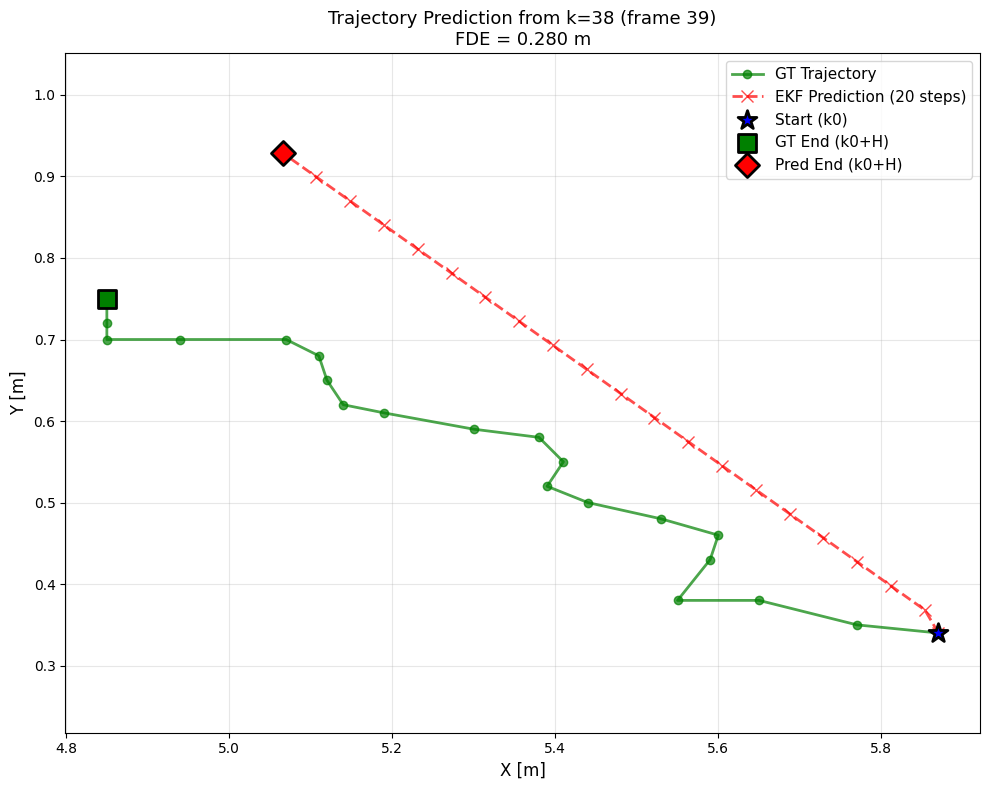

Plotted prediction window starting at k=38 (frame 39)


In [16]:
# Visualization 1: Example trajectory prediction
k0 = max_start // 2  # Choose middle window

# Generate predictions from k0
x_temp = x_filt[k0].copy()
preds_x = []
preds_y = []

for h in range(1, H + 1):
    x_temp = F_mat @ x_temp
    preds_x.append(x_temp[0])
    preds_y.append(x_temp[1])

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# GT trajectory
ax.plot(X_gt[k0:k0+H+1], Y_gt[k0:k0+H+1], 
        marker="o", markersize=6, linewidth=2, 
        label="GT Trajectory", color="green", alpha=0.7)

# Predicted trajectory
ax.plot([X_gt[k0]] + preds_x, [Y_gt[k0]] + preds_y,
        marker="x", markersize=8, linewidth=2, linestyle="--",
        label=f"EKF Prediction ({H} steps)", color="red", alpha=0.7)

# Mark start and end points
ax.scatter(X_gt[k0], Y_gt[k0], s=200, c="blue", marker="*", 
          edgecolors="black", linewidths=2, label="Start (k0)", zorder=5)
ax.scatter(X_gt[k0+H], Y_gt[k0+H], s=150, c="green", marker="s",
          edgecolors="black", linewidths=2, label="GT End (k0+H)", zorder=5)
ax.scatter(preds_x[-1], preds_y[-1], s=150, c="red", marker="D",
          edgecolors="black", linewidths=2, label="Pred End (k0+H)", zorder=5)

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlabel("X [m]", fontsize=12)
ax.set_ylabel("Y [m]", fontsize=12)
ax.set_title(f"Trajectory Prediction from k={k0} (frame {frame_ids[k0]})\n" + 
            f"FDE = {np.sqrt((preds_x[-1]-X_gt[k0+H])**2 + (preds_y[-1]-Y_gt[k0+H])**2):.3f} m",
            fontsize=13)
plt.tight_layout()
plt.show()

print(f"Plotted prediction window starting at k={k0} (frame {frame_ids[k0]})")

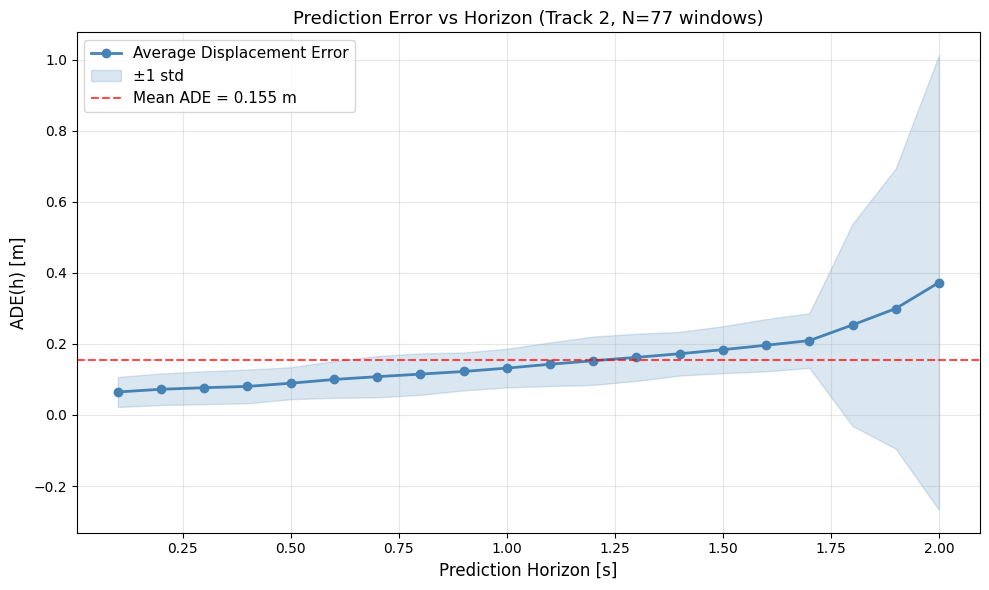

ADE growth: 0.0647 m (0.1s) → 0.3726 m (2.0s)
Growth rate: 0.1540 m/s


In [17]:
# Visualization 2: ADE vs prediction horizon
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

horizons = np.arange(1, H + 1)
time_horizons = horizons * dt_default

ax.plot(time_horizons, ade_per_h, marker="o", markersize=6, 
        linewidth=2, color="steelblue", label="Average Displacement Error")

# Add error bars (std across windows)
ade_std_per_h = per_h_errors.std(axis=1)
ax.fill_between(time_horizons, 
                ade_per_h - ade_std_per_h,
                ade_per_h + ade_std_per_h,
                alpha=0.2, color="steelblue", label="±1 std")

ax.grid(True, alpha=0.3)
ax.set_xlabel("Prediction Horizon [s]", fontsize=12)
ax.set_ylabel("ADE(h) [m]", fontsize=12)
ax.set_title(f"Prediction Error vs Horizon (Track {track_id}, N={max_start+1} windows)", 
            fontsize=13)
ax.legend(fontsize=11)

# Add reference lines
ax.axhline(ade_mean, color="red", linestyle="--", linewidth=1.5, 
          alpha=0.7, label=f"Mean ADE = {ade_mean:.3f} m")
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"ADE growth: {ade_per_h[0]:.4f} m (0.1s) → {ade_per_h[-1]:.4f} m (2.0s)")
print(f"Growth rate: {(ade_per_h[-1] - ade_per_h[0]) / (H * dt_default):.4f} m/s")

## 7. Summary and Observations

### Key Findings

**Performance Metrics (H=20, ~2 seconds):**
- ADE quantifies the average prediction error over the entire prediction window
- FDE measures the final endpoint error
- Short-horizon predictions (h≤5, ≤0.5s) typically show lower errors

### Observations

1. **Ideal Measurement Scenario**: 
   - This evaluation uses GT positions as measurements (σ_meas = 0.1m)
   - Represents best-case performance with perfect detection and localization
   - Real-world performance will degrade with detector/BEV transformation errors

2. **Error Growth with Horizon**:
   - Prediction error increases with horizon due to:
     - Accumulation of process noise
     - Pedestrian motion non-linearity (CV model limitations)
     - Lack of intent/context modeling
   
3. **CV Model Limitations**:
   - Assumes constant velocity (linear extrapolation)
   - Cannot predict turns, stops, or acceleration changes
   - Suitable for short-term prediction (~1-2 seconds)
   - For longer horizons, need more sophisticated models (e.g., trajectory prediction networks)

4. **Practical Implications**:
   - For collision warning systems: Focus on short horizons (0.5-1.0s)
   - For trajectory planning: Consider uncertainty bounds (covariance P)
   - Tuning R based on actual detector performance is critical

### Next Steps

- Integrate with real detector outputs (YOLO-pose + BEV transformation)
- Tune measurement noise R based on detector localization errors
- Evaluate impact of missed detections and ID switches
- Consider adaptive models (e.g., maneuver detection, multi-model filtering)